# Few-Shot Feature Fusion: CLIP + DINOv2 on CIFAR-10

This notebook builds and compares five few-shot classification pipelines on CIFAR-10:

1. **CLIP features** + linear probe
2. **DINOv2 features** + linear probe
3. **Concatenated CLIP + DINOv2 features** + linear probe
4. **CLIP + DINOv2** with a small trainable fusion layer (projection to a common dim, then fusion, then classifier), trained jointly
5. **Tip-Adapter** (training-free, cache-based adapter on top of CLIP's zero-shot classifier) **vs.** a **cache-based classifier on DINOv2 features** (no text tower, so it's a pure similarity-cache classifier)

**Pipeline shape for every experiment:**
`image -> [CLIP encoder, DINOv2 encoder] -> L2-normalize -> (project to common dim if needed) -> fuse -> few-shot classifier -> accuracy`

Backbones are **frozen** throughout — only probes / fusion heads / adapters are trained, which is standard practice for few-shot evaluation of foundation-model features.

> **Before running:** this notebook downloads pretrained CLIP and DINOv2 checkpoints from the Hugging Face Hub and the CIFAR-10 dataset via torchvision, so it needs internet access and, ideally, a GPU. Feature extraction for the two backbones is the slow part; everything downstream (probes, fusion, adapters) is cheap since it only touches cached feature vectors.


## 1. Setup

In [1]:
# If a package is missing, uncomment and run:
# %pip install torch torchvision transformers scikit-learn matplotlib ftfy regex --quiet


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from transformers import CLIPModel, CLIPProcessor, AutoModel, AutoImageProcessor
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## 2. Config

Tune `N_SHOT` (labeled images per class used for training the probes/adapters) and
`N_TEST_PER_CLASS` (how many test images per class to evaluate on — CIFAR-10's full
10k-image test set works too, just slower).

In [3]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CIFAR10_CLASSES)

N_SHOT = 16                 # few-shot: labeled images per class for training
N_TEST_PER_CLASS = 100      # images per class used for evaluation (subset of the 10k test set)

COMMON_DIM = 256            # shared projection dimension for the fusion experiment

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
DINO_MODEL_NAME = "facebook/dinov2-base"

DATA_ROOT = "./data"


## 3. Data: few-shot CIFAR-10 sampler

We load raw CIFAR-10 (PIL images, no tensor transform yet) so that each backbone's own
image processor can be applied at feature-extraction time. We then build:
- a **few-shot support set**: `N_SHOT` images per class (used to train every probe / adapter / fusion head)
- a **balanced evaluation subset**: `N_TEST_PER_CLASS` images per class from the official test split


In [4]:
def pil_identity(img):
    return img

train_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)

def build_fewshot_indices(dataset, n_per_class, seed=SEED):
    rng = random.Random(seed)
    by_class = {c: [] for c in range(NUM_CLASSES)}
    for idx, (_, label) in enumerate(dataset):
        by_class[label].append(idx)
    chosen = []
    for c in range(NUM_CLASSES):
        idxs = by_class[c][:]
        rng.shuffle(idxs)
        chosen.extend(idxs[:n_per_class])
    rng.shuffle(chosen)
    return chosen

train_indices = build_fewshot_indices(train_raw, N_SHOT)
test_indices = build_fewshot_indices(test_raw, N_TEST_PER_CLASS, seed=SEED + 1)

train_subset = Subset(train_raw, train_indices)
test_subset = Subset(test_raw, test_indices)

print(f"Few-shot train set: {len(train_subset)} images ({N_SHOT}-shot x {NUM_CLASSES} classes)")
print(f"Evaluation set:     {len(test_subset)} images ({N_TEST_PER_CLASS}/class x {NUM_CLASSES} classes)")


Few-shot train set: 160 images (16-shot x 10 classes)
Evaluation set:     1000 images (100/class x 10 classes)


## 4. Load frozen backbones

Both CLIP and DINOv2 are loaded once, frozen (`requires_grad_(False)`), and set to `eval()` mode.
Each has its own `Processor`/`ImageProcessor` that handles resizing, normalization, etc.,
so we feed raw PIL images into each processor independently rather than sharing one transform.

In [5]:
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
for p in clip_model.parameters():
    p.requires_grad_(False)

dino_model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(DEVICE).eval()
dino_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_NAME)
for p in dino_model.parameters():
    p.requires_grad_(False)

CLIP_DIM = clip_model.config.projection_dim          # 512 for ViT-B/32
DINO_DIM = dino_model.config.hidden_size              # 768 for dinov2-base
print("CLIP feature dim:", CLIP_DIM)
print("DINOv2 feature dim:", DINO_DIM)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLIP feature dim: 512
DINOv2 feature dim: 768


## 5. Feature extraction

We extract, for every image:
- a **CLIP image embedding** (`get_image_features`, already projected into CLIP's joint embedding space)
- a **DINOv2 embedding** (the `[CLS]` token of the last hidden state)

Both are **L2-normalized** immediately after extraction — this matters a lot for
feature fusion and for cache-based / cosine-similarity methods like Tip-Adapter.

In [6]:
def _unwrap_embeds(out):
    """Some transformers versions return a raw tensor from get_image_features /
    get_text_features; others return a ModelOutput-like wrapper. Normalize to a tensor."""
    if torch.is_tensor(out):
        return out
    candidate = getattr(out, "image_embeds", None)
    if candidate is None:
        candidate = getattr(out, "text_embeds", None)
    if candidate is None:
        candidate = getattr(out, "pooler_output", None)
    if candidate is None:
        candidate = out[0]
    return candidate

@torch.no_grad()
def extract_clip_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
        emb = clip_model.get_image_features(**inputs)
        emb = _unwrap_embeds(emb)
        emb = F.normalize(emb, dim=-1)
        feats.append(emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)

@torch.no_grad()
def extract_dino_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        cls_emb = out.last_hidden_state[:, 0, :]      # [CLS] token
        cls_emb = F.normalize(cls_emb, dim=-1)
        feats.append(cls_emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)

print("Extracting CLIP features...")
train_clip, train_labels = extract_clip_features(train_subset)
test_clip, test_labels = extract_clip_features(test_subset)

print("Extracting DINOv2 features...")
train_dino, train_labels_d = extract_dino_features(train_subset)
test_dino, test_labels_d = extract_dino_features(test_subset)

# sanity check: label ordering must match between the two extractions
assert torch.equal(train_labels, train_labels_d)
assert torch.equal(test_labels, test_labels_d)

print("train_clip:", train_clip.shape, " train_dino:", train_dino.shape)
print("test_clip: ", test_clip.shape, " test_dino: ", test_dino.shape)


Extracting CLIP features...
Extracting DINOv2 features...
train_clip: torch.Size([160, 512])  train_dino: torch.Size([160, 768])
test_clip:  torch.Size([1000, 512])  test_dino:  torch.Size([1000, 768])


## 6. Generic linear-probe trainer

A single reusable routine trains a `nn.Linear(in_dim, num_classes)` (optionally preceded
by an arbitrary trainable `nn.Module`, e.g. a fusion head) with Adam + cross-entropy on the
few-shot support set, then reports accuracy on the held-out evaluation set. Since the
few-shot support set is tiny, we train full-batch for a fixed number of epochs with weight decay
to keep the probe from overfitting.

In [7]:
def train_probe(train_feats, train_labels, test_feats, test_labels, in_dim,
                 backbone_module=None, epochs=300, lr=1e-2, weight_decay=1e-3, verbose=False):
    """
    train_feats/test_feats: raw (already-normalized) input features, shape [N, in_dim]
    backbone_module: optional trainable nn.Module applied to features before the linear head
                      (e.g. a projection+fusion network). If None, the head is applied directly.
    Returns: test accuracy (float), trained head (and backbone_module, if given)
    """
    train_feats = train_feats.to(DEVICE)
    test_feats = test_feats.to(DEVICE)
    train_labels = train_labels.to(DEVICE)
    test_labels = test_labels.to(DEVICE)

    head_in_dim = in_dim if backbone_module is None else backbone_module.out_dim
    head = nn.Linear(head_in_dim, NUM_CLASSES).to(DEVICE)

    params = list(head.parameters())
    if backbone_module is not None:
        params += list(backbone_module.parameters())
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    for epoch in range(epochs):
        head.train()
        if backbone_module is not None:
            backbone_module.train()
        optimizer.zero_grad()
        feats = backbone_module(train_feats) if backbone_module is not None else train_feats
        logits = head(feats)
        loss = F.cross_entropy(logits, train_labels)
        loss.backward()
        optimizer.step()
        if verbose and (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"  epoch {epoch+1}/{epochs}  loss={loss.item():.4f}")

    head.eval()
    if backbone_module is not None:
        backbone_module.eval()
    with torch.no_grad():
        feats = backbone_module(test_feats) if backbone_module is not None else test_feats
        preds = head(feats).argmax(dim=-1)
        acc = (preds == test_labels).float().mean().item()
    return acc, head, backbone_module


## 7. Experiment 1 & 2: single-modality linear probes

In [8]:
acc_clip, _, _ = train_probe(train_clip, train_labels, test_clip, test_labels, in_dim=CLIP_DIM)
print(f"[1] CLIP features + linear probe:    {acc_clip*100:.2f}%")

acc_dino, _, _ = train_probe(train_dino, train_labels, test_dino, test_labels, in_dim=DINO_DIM)
print(f"[2] DINOv2 features + linear probe:  {acc_dino*100:.2f}%")


[1] CLIP features + linear probe:    89.60%
[2] DINOv2 features + linear probe:  96.10%


## 8. Experiment 3: concatenated features + linear probe

Simple late fusion: L2-normalized CLIP and DINOv2 embeddings are concatenated into one
`(CLIP_DIM + DINO_DIM)`-dim vector per image, and a single linear probe is trained on top.
No learned projection is involved here — it's the "free" fusion baseline.

In [9]:
train_concat = torch.cat([train_clip, train_dino], dim=-1)
test_concat = torch.cat([test_clip, test_dino], dim=-1)

acc_concat, _, _ = train_probe(train_concat, train_labels, test_concat, test_labels,
                                in_dim=CLIP_DIM + DINO_DIM)
print(f"[3] Concat(CLIP, DINOv2) + linear probe: {acc_concat*100:.2f}%")


[3] Concat(CLIP, DINOv2) + linear probe: 96.80%


## 9. Experiment 4: learned projection + small trainable fusion layer

Here the "common dimension" step actually does something: each modality is projected
by its own trainable linear layer into a shared `COMMON_DIM`-dim space, the two projections
are concatenated and passed through a small 2-layer MLP fusion block, and a linear head sits
on top. The projections + fusion block + head are all trained **jointly** end-to-end
(backbones stay frozen — only their cached features are used as input).

In [10]:
class FusionHead(nn.Module):
    """Projects CLIP + DINOv2 features into a common space and fuses them."""
    def __init__(self, clip_dim, dino_dim, common_dim):
        super().__init__()
        self.proj_clip = nn.Linear(clip_dim, common_dim)
        self.proj_dino = nn.Linear(dino_dim, common_dim)
        self.fusion = nn.Sequential(
            nn.Linear(common_dim * 2, common_dim),
            nn.ReLU(),
            nn.Linear(common_dim, common_dim),
        )
        self.out_dim = common_dim
        self.clip_dim = clip_dim
        self.dino_dim = dino_dim

    def forward(self, x):
        # x is the concatenated [clip_dim + dino_dim] input feature
        clip_part = x[:, :self.clip_dim]
        dino_part = x[:, self.clip_dim:]
        p_clip = F.normalize(self.proj_clip(clip_part), dim=-1)
        p_dino = F.normalize(self.proj_dino(dino_part), dim=-1)
        fused = self.fusion(torch.cat([p_clip, p_dino], dim=-1))
        return fused

fusion_module = FusionHead(CLIP_DIM, DINO_DIM, COMMON_DIM).to(DEVICE)

acc_fusion, trained_head, trained_fusion = train_probe(
    train_concat, train_labels, test_concat, test_labels,
    in_dim=CLIP_DIM + DINO_DIM, backbone_module=fusion_module,
    epochs=400, lr=5e-3, weight_decay=1e-3,
)
print(f"[4] CLIP+DINOv2 + trainable fusion + linear probe: {acc_fusion*100:.2f}%")


[4] CLIP+DINOv2 + trainable fusion + linear probe: 94.30%


## 10. Experiment 5a: Tip-Adapter on CLIP features

[Tip-Adapter](https://arxiv.org/abs/2207.09519) is a **training-free** adapter for
CLIP few-shot classification. It builds a "key-value cache" directly from the few-shot
support features (keys = normalized image features, values = one-hot labels), and combines:

- CLIP's own **zero-shot** prediction, from cosine similarity between a test image
  embedding and CLIP **text** embeddings of prompts like `"a photo of a {class}"`
- a **cache-based** prediction, from an affinity-weighted vote over the cached support
  features (nearby cached examples vote for their class, with an exponential kernel controlled by `beta`)

`alpha` controls how much weight the cache term gets relative to the zero-shot term.
We use the paper's default hyperparameters (`beta=5.5`, `alpha=1.0`); in practice these
are tuned on a held-out split, which you can do by grid-searching against a small
validation split of the few-shot set.

In [11]:
@torch.no_grad()
def build_clip_zeroshot_weights(class_names, template="a photo of a {}."):
    prompts = [template.format(c) for c in class_names]
    inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
    text_feats = clip_model.get_text_features(**inputs)
    text_feats = _unwrap_embeds(text_feats)
    text_feats = F.normalize(text_feats, dim=-1)
    return text_feats  # [num_classes, CLIP_DIM]

clip_zeroshot_weights = build_clip_zeroshot_weights(CIFAR10_CLASSES)

def tip_adapter_predict(train_feats, train_labels, test_feats, zeroshot_weights,
                         beta=5.5, alpha=1.0, logit_scale=100.0):
    # Cache: keys = few-shot features, values = one-hot labels
    cache_keys = train_feats.to(DEVICE)                                  # [N_shot*C, dim]
    cache_values = F.one_hot(train_labels.to(DEVICE), NUM_CLASSES).float()  # [N_shot*C, C]

    test_feats = test_feats.to(DEVICE)

    # zero-shot term
    zeroshot_logits = logit_scale * test_feats @ zeroshot_weights.T      # [N_test, C]

    # cache term: affinity via cosine similarity (features are already L2-normalized)
    affinity = test_feats @ cache_keys.T                                  # [N_test, N_shot*C]
    cache_logits = ((-1) * (beta - beta * affinity)).exp() @ cache_values # [N_test, C]

    tip_logits = zeroshot_logits + alpha * cache_logits
    return tip_logits

# Plain CLIP zero-shot accuracy, for reference
zeroshot_logits_only = 100.0 * test_clip.to(DEVICE) @ clip_zeroshot_weights.T
acc_clip_zeroshot = (zeroshot_logits_only.argmax(-1).cpu() == test_labels).float().mean().item()
print(f"      (reference) CLIP zero-shot only:        {acc_clip_zeroshot*100:.2f}%")

tip_logits = tip_adapter_predict(train_clip, train_labels, test_clip, clip_zeroshot_weights,
                                  beta=5.5, alpha=1.0)
acc_tip = (tip_logits.argmax(-1).cpu() == test_labels).float().mean().item()
print(f"[5a] Tip-Adapter (CLIP, training-free):    {acc_tip*100:.2f}%")


      (reference) CLIP zero-shot only:        89.50%
[5a] Tip-Adapter (CLIP, training-free):    92.00%


## 11. Experiment 5b: cache-based classifier on DINOv2 features

DINOv2 has no text tower, so there is no zero-shot term available — this is the fair
comparison point for the *cache* component of Tip-Adapter in isolation. We reuse the same
affinity-cache mechanism (few-shot features as keys, one-hot labels as values, exponential
kernel on cosine similarity) but classify using **only** the cache logits.

In [12]:
def cache_classifier_predict(train_feats, train_labels, test_feats, beta=5.5):
    cache_keys = train_feats.to(DEVICE)
    cache_values = F.one_hot(train_labels.to(DEVICE), NUM_CLASSES).float()
    test_feats = test_feats.to(DEVICE)

    affinity = test_feats @ cache_keys.T
    cache_logits = ((-1) * (beta - beta * affinity)).exp() @ cache_values
    return cache_logits

dino_cache_logits = cache_classifier_predict(train_dino, train_labels, test_dino, beta=5.5)
acc_dino_cache = (dino_cache_logits.argmax(-1).cpu() == test_labels).float().mean().item()
print(f"[5b] Cache-based classifier (DINOv2, training-free): {acc_dino_cache*100:.2f}%")


[5b] Cache-based classifier (DINOv2, training-free): 94.10%


### Optional: quick `beta` sweep

Both cache methods are sensitive to the sharpness hyperparameter `beta`. A cheap way to
tune it without a separate validation set is to sweep a few values and keep the one that
maximizes support-set (train) accuracy, then re-evaluate on the test set. This cell is
optional — the fixed `beta=5.5` above already follows the Tip-Adapter paper's default.

In [13]:
def sweep_beta(betas, predict_fn, *args, **kwargs):
    best_beta, best_train_acc = None, -1
    for b in betas:
        logits = predict_fn(*args, beta=b, **kwargs)
        # NOTE: pass train_feats as the 'test_feats' arg here to score on the support set itself
        pass
    return best_beta

betas_to_try = [1.0, 3.0, 5.5, 8.0, 12.0]

# Tip-Adapter beta sweep (scored on the support set as a cheap proxy)
best_tip_beta, best_tip_train_acc = None, -1
for b in betas_to_try:
    logits = tip_adapter_predict(train_clip, train_labels, train_clip, clip_zeroshot_weights, beta=b, alpha=1.0)
    acc = (logits.argmax(-1).cpu() == train_labels).float().mean().item()
    if acc > best_tip_train_acc:
        best_tip_train_acc, best_tip_beta = acc, b
tip_logits_tuned = tip_adapter_predict(train_clip, train_labels, test_clip, clip_zeroshot_weights,
                                        beta=best_tip_beta, alpha=1.0)
acc_tip_tuned = (tip_logits_tuned.argmax(-1).cpu() == test_labels).float().mean().item()
print(f"Tip-Adapter tuned beta={best_tip_beta} -> test acc {acc_tip_tuned*100:.2f}%")

# DINOv2 cache classifier beta sweep
best_dino_beta, best_dino_train_acc = None, -1
for b in betas_to_try:
    logits = cache_classifier_predict(train_dino, train_labels, train_dino, beta=b)
    acc = (logits.argmax(-1).cpu() == train_labels).float().mean().item()
    if acc > best_dino_train_acc:
        best_dino_train_acc, best_dino_beta = acc, b
dino_logits_tuned = cache_classifier_predict(train_dino, train_labels, test_dino, beta=best_dino_beta)
acc_dino_cache_tuned = (dino_logits_tuned.argmax(-1).cpu() == test_labels).float().mean().item()
print(f"DINOv2 cache tuned beta={best_dino_beta} -> test acc {acc_dino_cache_tuned*100:.2f}%")


Tip-Adapter tuned beta=12.0 -> test acc 91.80%
DINOv2 cache tuned beta=1.0 -> test acc 92.40%


## 12. Results summary

In [14]:
results = {
    "1. CLIP + linear probe": acc_clip,
    "2. DINOv2 + linear probe": acc_dino,
    "3. Concat(CLIP,DINOv2) + linear probe": acc_concat,
    "4. CLIP+DINOv2 + trainable fusion": acc_fusion,
    "5a. Tip-Adapter (CLIP)": acc_tip,
    "5b. Cache classifier (DINOv2)": acc_dino_cache,
}

print(f"{'Method':45s} | Accuracy")
print("-" * 60)
for name, acc in results.items():
    print(f"{name:45s} | {acc*100:6.2f}%")


Method                                        | Accuracy
------------------------------------------------------------
1. CLIP + linear probe                        |  89.60%
2. DINOv2 + linear probe                      |  96.10%
3. Concat(CLIP,DINOv2) + linear probe         |  96.80%
4. CLIP+DINOv2 + trainable fusion             |  94.30%
5a. Tip-Adapter (CLIP)                        |  92.00%
5b. Cache classifier (DINOv2)                 |  94.10%


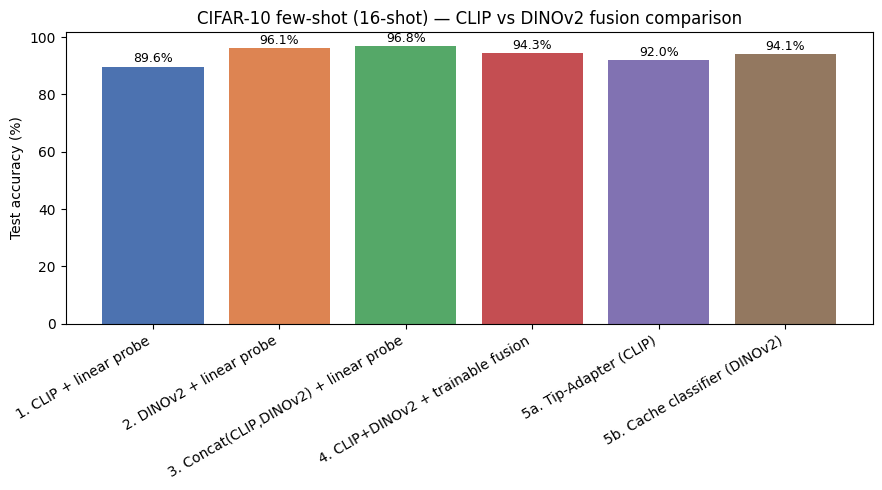

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
accs = [v * 100 for v in results.values()]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
bars = ax.bar(range(len(names)), accs, color=colors[:len(names)])
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Test accuracy (%)")
ax.set_title(f"CIFAR-10 few-shot ({N_SHOT}-shot) — CLIP vs DINOv2 fusion comparison")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{acc:.1f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Notes & things worth trying next

- **Shot count**: re-run with `N_SHOT` at 1/2/4/8/16/32 to plot a few-shot learning curve per method — this is usually more informative than a single operating point.
- **Backbone size**: swapping in `openai/clip-vit-large-patch14` and `facebook/dinov2-large` should raise every number but also cost more to extract.
- **Fusion architecture**: experiment 4's fusion block is intentionally simple (concat + 2-layer MLP). Gated fusion (`sigmoid` gate over each modality) or cross-attention between the two modalities' tokens (using DINOv2's patch tokens rather than just `[CLS]`) are natural next steps.
- **Tip-Adapter-F**: the original paper also proposes fine-tuning the cache *keys* (not just reading from them) with a few gradient steps — that typically closes most of the remaining gap to a fully trained probe, at the cost of no longer being training-free.
- **Fairer comparison for 5b**: since DINOv2 has no text tower, its "zero-shot" term is missing by construction — comparison 5 is really testing how much CLIP's language alignment (via the zero-shot term) adds on top of a cache mechanism both models can use equally.
